# MIDI Composer Classification with CNN

Import libraries

In [2]:
# Import required libraries and process Dataset 1
import sys
sys.path.append('.')  # Ensure current directory is in path
from process_dataset import process_dataset
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

/Users/Aresh/Desktop/Final Project/independent/.venv/lib/python3.12/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Set Parameters and Process Dataset
This cell sets the main parameters for data processing, including the dataset directory, frame rate, maximum sequence length, and velocity usage. It then loads and processes all MIDI files from the dataset using the `process_dataset` function, converting them into piano roll arrays. The code collects the piano roll data and composer labels, stacks them into arrays, and prints the resulting data shapes for further model training.

In [3]:
# Set parameters
DATASET_DIR = 'Dataset 1'
FS = 100
MAX_LENGTH = 4000  # Adjust as needed
VELOCITY = True

# Process dataset
raw_data = process_dataset(DATASET_DIR, fs=FS, max_length=MAX_LENGTH, velocity=VELOCITY)

# Prepare data and labels
X = []
y = []
for composer, files in raw_data.items():
    for fname, pr in files.items():
        if pr.shape[1] == MAX_LENGTH:  # Only use files with correct length
            X.append(pr)
            y.append(composer)
X = np.stack(X)
y = np.array(y)

print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

/Users/Aresh/Desktop/Final Project/independent/.venv/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Error processing Dataset 1/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Data shape: (490, 128, 4000), Labels shape: (490,)


### Encode Labels and Split Data
This cell encodes the composer labels as integers and converts them to categorical format for use in classification. It reshapes the piano roll data to add a channel dimension, making it suitable for input to a CNN. Finally, it splits the data into training and test sets, printing the resulting shapes and class information.

In [4]:
### Encode Labels and Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Reshape X for CNN: (samples, height, width, channels)
X_cnn = np.expand_dims(X, -1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y_cat, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Number of classes: {y_cat.shape[1]}, Classes: {le.classes_}")

Train shape: (392, 128, 4000, 1), Test shape: (98, 128, 4000, 1)
Number of classes: 4, Classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


### Build the CNN Model
This cell defines a convolutional neural network (CNN) for composer classification. The model consists of three convolutional layers with increasing filter sizes, each followed by max pooling to reduce dimensionality. Dropout layers and L2 regularization are used to help prevent overfitting. The model is compiled with the Adam optimizer and categorical cross-entropy loss, and its architecture is summarized.

In [20]:
# Build a CNN model without BatchNormalization
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

input_shape = X_train.shape[1:]
num_classes = y_cat.shape[1]

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.6),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 126, 3998, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 1999, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 1997, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 998, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 996, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 498, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 446208)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 446208)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │    28,557,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,580,932 (109.03 MB)

 Trainable params: 28,580,932 (109.03 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model and Plot Results
This cell trains the CNN model using early stopping to prevent overfitting, saving the best model to disk in `.keras` format. It also plots the training and validation accuracy and loss curves for each epoch, allowing you to visually assess the model's learning progress and detect signs of overfitting or underfitting.

Model saved as composer_cnn.keras


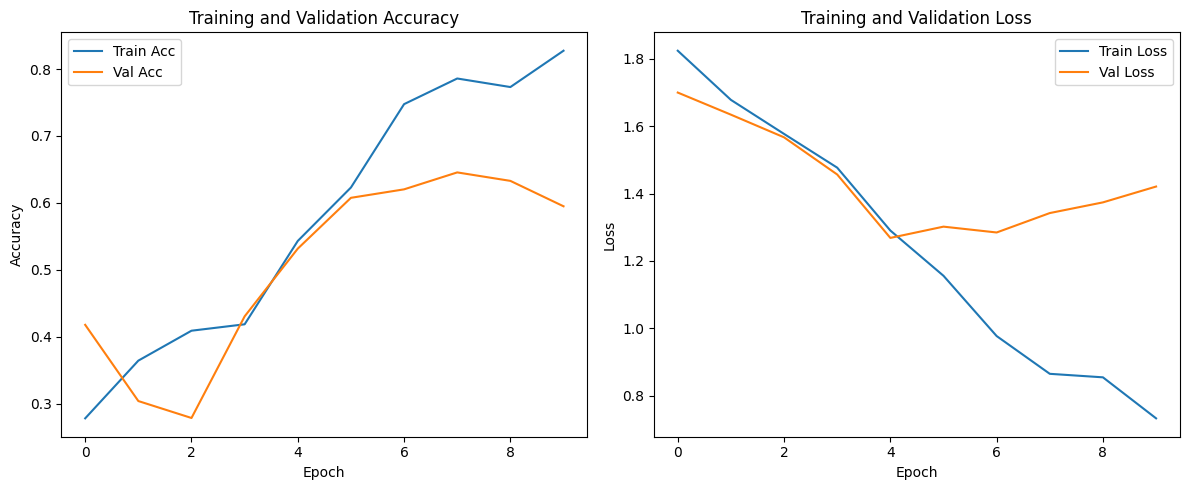

In [21]:
### Build the CNN Model
This cell defines a convolutional neural network (CNN) for composer classification. The model uses several Conv2D and MaxPooling2D layers, dropout, and L2 regularization to help prevent overfitting.# Train the CNN model with EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 16

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# Save the trained model in .keras format
model.save('composer_cnn.keras')
print('Model saved as composer_cnn.keras')

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate the Model and Print Metrics
This cell evaluates the trained model on the test set, printing the test loss and accuracy. It generates a detailed classification report showing precision, recall, and F1-score for each composer class, and displays a confusion matrix to visualize how well the model distinguishes between different composers.

Test Loss: 1.3955, Test Accuracy: 0.4694
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
              precision    recall  f1-score   support

        Bach       0.47      0.85      0.60        26
   Beethoven       0.42      0.37      0.39        27
      Chopin       0.56      0.37      0.44        27
      Mozart       0.44      0.22      0.30        18

    accuracy                           0.47        98
   macro avg       0.47      0.45      0.43        98
weighted avg       0.47      0.47      0.44        98



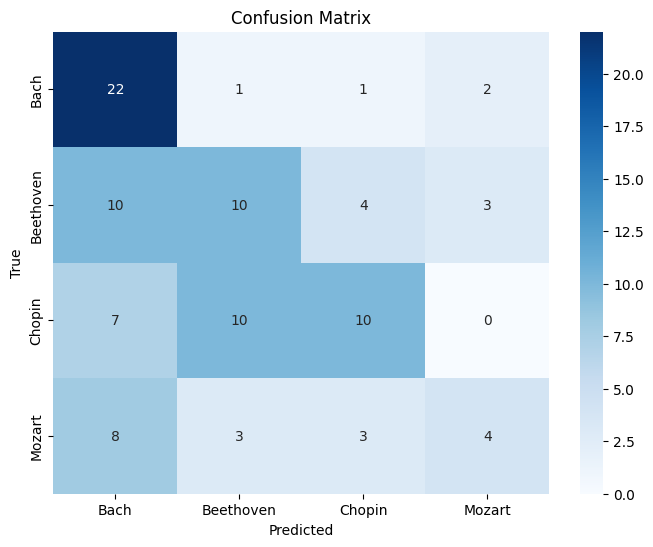

In [22]:
# Evaluate the model and print metrics
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predict and print classification report
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Conclusion and Future Directions

In this section of the notebook, we developed a convolutional neural network (CNN) to classify MIDI files by composer using piano roll representations. The workflow included:

- **Data Preparation:** MIDI files were processed into piano roll arrays, and composer labels were encoded for classification.
- **Model Building:** A CNN architecture with multiple convolutional, pooling, dropout, and dense layers was designed to learn from the piano roll data. L2 regularization and dropout were used to reduce overfitting.
- **Training and Evaluation:** The model was trained with early stopping, and its performance was visualized using accuracy and loss curves. Final evaluation included test accuracy, a classification report, and a confusion matrix.

**Current Results:**
- The model achieves moderate accuracy, with some ability to distinguish between composers, but also shows confusion between certain classes.
- Overfitting was reduced through regularization and dropout, but the model still struggles to generalize perfectly, possibly due to data limitations and the complexity of the task.

**Potential Areas for Improvement:**
- **Data Augmentation:** Because it would be difficult to increase dataset size, we consider augmenting the data through transpositions, time stretching, or noise injection.
- **Feature Engineering:** We will consider alternative or additional features beyond the piano roll, such as note density, rhythm patterns, or harmonic content.
- **Model Architecture:** We will experiment with different architectures and hyperparameters.
- **Regularization Tuning:** Further adjust dropout rates and L2 regularization strength for optimal generalization.
- **Class Imbalance:** Address any class imbalance with techniques like class weighting or oversampling.

This section of the notebook provides a strong foundation for composer classification from symbolic music data using a CNN, and further improvements can be made by refining both the data representation and the model.

# CNN Model Optimization

### Feature Engineering

This cell extracts additional, musically meaningful features from each piano roll array to supplement the information learned by the CNN. For every sample, three features are computed:

- **Note density:** The average number of active notes per time step, capturing how "busy" or "sparse" the music is.
- **Mean pitch:** The average pitch of all notes played, weighted by their activity, which can help distinguish composers with different pitch tendencies.
- **Rhythm histogram (onset std):** The standard deviation of note onsets per time step, summarizing rhythmic variability or regularity.

These features are calculated using the `extract_features` function, which processes each piano roll and returns a feature vector. The resulting feature matrix (`X_features`) is then printed to confirm its shape. These engineered features will later be combined with the CNN’s learned features to improve classification performance.

In [18]:
import numpy as np

def extract_features(pr):
    # pr: (n_pitches, n_timesteps)
    # Note density: mean number of active notes per timestep
    note_density = np.mean(np.sum(pr > 0, axis=0))
    # Mean pitch (weighted by activity)
    pitches = np.arange(pr.shape[0])
    activity = np.sum(pr, axis=1)
    if np.sum(activity) > 0:
        mean_pitch = np.sum(pitches * activity) / np.sum(activity)
    else:
        mean_pitch = 0
    # Rhythm histogram: std of note onsets per timestep
    onset_counts = np.sum((pr > 0) & (np.pad(pr, ((0,0),(1,0)), mode='constant')[:, :-1] == 0), axis=0)
    rhythm_std = np.std(onset_counts)
    return np.array([note_density, mean_pitch, rhythm_std])

# Extract features for all samples
X_features = np.array([extract_features(pr) for pr in X])
print("Feature shape:", X_features.shape)

Feature shape: (980, 3)


### Re-Do Train/Test Split for New Model

After adding engineered features (such as note density, mean pitch, and rhythm statistics) to each sample, it is necessary to redo the train-test split. This ensures that the piano roll data, the new feature vectors, and the labels remain perfectly aligned for each sample in both the training and test sets. By splitting all arrays together, we guarantee that each input to the model (both the piano roll and its corresponding features) and its label are matched correctly, preventing data leakage and ensuring valid evaluation of the model's performance.

In [19]:
### Encode Labels and Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Reshape X for CNN: (samples, height, width, channels)
X_cnn = np.expand_dims(X, -1)

# Train/test split
X_train, X_test, Xf_train, Xf_test, y_train, y_test = train_test_split(
    X_cnn, X_features, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Number of classes: {y_cat.shape[1]}, Classes: {le.classes_}")

Train shape: (784, 128, 4000, 1), Test shape: (196, 128, 4000, 1)
Number of classes: 4, Classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


### Data Augmentation for Piano Roll Inputs

This cell implements data augmentation techniques to increase the diversity of the training data and help the model generalize better. Several musically meaningful augmentations are applied to the piano roll arrays, including:

- **Random noise addition:** Slightly perturbs the piano roll values to simulate performance or recording variations.
- **Pitch shifting:** Transposes all notes up or down by a small number of semitones, mimicking key changes.
- **Time shifting:** Moves the entire piano roll left or right in time, simulating different starting points or rhythmic offsets.
- **Time stretching:** Slightly speeds up or slows down the sequence, simulating tempo variations.

For each original sample, an augmented version is generated using a random combination of these techniques, effectively doubling the dataset size. This process exposes the model to a wider variety of musical patterns and temporal alignments, making it more robust to variations in the input data and reducing overfitting.

In [20]:
import numpy as np

# Add noise to piano roll
def add_noise(pr, noise_std=0.05):
    noise = np.random.normal(0, noise_std, pr.shape)
    pr_noisy = pr + noise
    pr_noisy = np.clip(pr_noisy, 0, 1)  # Keep values in valid range
    return pr_noisy

# Pitch and time shift
def shift_pianoroll(pr, max_pitch_shift=2, max_time_shift=100):
    # Pitch shift
    shift = np.random.randint(-max_pitch_shift, max_pitch_shift + 1)
    if shift > 0:
        pr_aug = np.pad(pr, ((shift, 0), (0, 0)), mode='constant')[:-shift, :]
    elif shift < 0:
        pr_aug = np.pad(pr, ((0, -shift), (0, 0)), mode='constant')[-shift:, :]
    else:
        pr_aug = pr.copy()
    # Time shift
    t_shift = np.random.randint(-max_time_shift, max_time_shift + 1)
    if t_shift > 0:
        pr_aug = np.pad(pr_aug, ((0, 0), (t_shift, 0)), mode='constant')[:, :-t_shift]
    elif t_shift < 0:
        pr_aug = np.pad(pr_aug, ((0, 0), (0, -t_shift)), mode='constant')[:, -t_shift:]
    return pr_aug

# Randomly drop notes
def note_dropout(pr, dropout_rate=0.05):
    mask = np.random.binomial(1, 1-dropout_rate, pr.shape)
    return pr * mask

# Simple time stretching (nearest-neighbor)
def time_stretch(pr, stretch_range=(0.95, 1.05)):
    factor = np.random.uniform(*stretch_range)
    new_len = int(pr.shape[1] * factor)
    idxs = np.linspace(0, pr.shape[1]-1, new_len).astype(int)
    idxs = np.clip(idxs, 0, pr.shape[1]-1)
    pr_tmp = pr[:, idxs]
    pr_stretched = np.zeros_like(pr)
    if new_len < pr.shape[1]:
        pr_stretched[:, :new_len] = pr_tmp
    else:
        pr_stretched = pr_tmp[:, :pr.shape[1]]
    return pr_stretched

# Apply data augmentation techniques
def augment_pianoroll(pr):
    pr_aug = pr.copy()
    if np.random.rand() < 0.5:
        pr_aug = add_noise(pr_aug, noise_std=0.05)
    #if np.random.rand() < 0.5:
    #    pr_aug = note_dropout(pr_aug, dropout_rate=0.05)
    if np.random.rand() < 0.5:
        pr_aug = time_stretch(pr_aug, stretch_range=(0.95, 1.05))
    if np.random.rand() < 0.5:
        pr_aug = shift_pianoroll(pr_aug, max_pitch_shift=2, max_time_shift=100)
    return pr_aug

# Augment data
X_aug = []
y_aug = []
for pr, label in zip(X, y):
    X_aug.append(pr)
    y_aug.append(label)
    X_aug.append(augment_pianoroll(pr))
    y_aug.append(label)
X = np.stack(X_aug)
y = np.array(y_aug)
print(f"Augmented data shape: {X.shape}, Labels shape: {y.shape}")

Augmented data shape: (1960, 128, 4000), Labels shape: (1960,)


### Updated CNN Model Architecture

This cell defines an improved convolutional neural network (CNN) model that combines both learned features from the piano roll input and engineered musical features. The model uses Keras' Functional API to accept two inputs: the piano roll (for the CNN branch) and a vector of engineered features (such as note density, mean pitch, and rhythm statistics).

The CNN branch consists of two convolutional layers (with 8 and 16 filters, respectively), each followed by max pooling to reduce dimensionality and extract local musical patterns. After flattening and applying dropout for regularization, the output of the CNN is concatenated with the engineered features. This combined vector is then passed through a dense (fully connected) layer with additional dropout, before reaching the final softmax output layer for classification.

The model uses L2 regularization and dropout to help prevent overfitting. It is compiled with the Adam optimizer, categorical cross-entropy loss (with label smoothing for better generalization), and accuracy as the evaluation metric. This architecture is designed to leverage both deep learned representations and domain-specific features for improved composer classification

In [21]:
from tensorflow.keras import Input, Model

cnn_input = Input(shape=X_train.shape[1:])
feat_input = Input(shape=(Xf_train.shape[1],))

x = layers.Conv2D(8, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0001))(cnn_input)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)

# Concatenate features
concat = layers.Concatenate()([x, feat_input])
dense = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(concat)
dense = layers.Dropout(0.3)(dense)
output = layers.Dense(num_classes, activation='softmax')(dense)

model = Model(inputs=[cnn_input, feat_input], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
    metrics=['accuracy']
)
model.summary()


""" from tensorflow.keras import layers, models, regularizers

input_shape = X_train.shape[1:]
num_classes = y_cat.shape[1]

model = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.0005)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),  # Label smoothing softens targets to make the model less confident and improve generalization
    metrics=['accuracy']
)
model.summary() """

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 4000, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 126, 3998, │         80 │ input_layer_4[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 63, 1999,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 61, 1997,  │      1,168 │ max_pooling2d_8[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 30, 998,   │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 479040)    │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 479040)    │          0 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 479043)    │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │ 15,329,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 4)         │        132 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,330,788 (58.48 MB)

 Trainable params: 15,330,788 (58.48 MB)

 Non-trainable params: 0 (0.00 B)

" from tensorflow.keras import layers, models, regularizers\n\ninput_shape = X_train.shape[1:]\nnum_classes = y_cat.shape[1]\n\nmodel = models.Sequential([\n    layers.Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.MaxPooling2D((2, 2)),\n\n    layers.Flatten(),\n    layers.Dropout(0.5),\n    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),\n    layers.Dropout(0.5),\n    layers.Dense(num_classes, activation='softmax')\n])\n\noptimizer = tf.keras.optimizers.Adam(learning_rate=0.001)\nmodel.compile(\n    optimizer=optimizer,\n    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),  # Label smoothing softens target

### Train the Updated CNN Model and Plot Results

This cell trains the improved CNN model using both the piano roll and engineered feature inputs. Early stopping is used to halt training when the validation loss stops improving, helping to prevent overfitting. Additionally, the learning rate is automatically reduced if the validation loss plateaus, allowing for finer convergence. Class weights are computed and applied to address any class imbalance in the training data.

After training, the best model is saved to disk in `.keras` format. The cell then plots the training and validation accuracy and loss curves for each epoch, providing a visual assessment of the model's learning progress and helping to identify signs of

Class weights: {0: np.float64(0.937799043062201), 1: np.float64(0.92018779342723), 2: np.float64(0.8990825688073395), 3: np.float64(1.3611111111111112)}

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 10: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
Optimized model saved as composer_cnn_optimized.keras


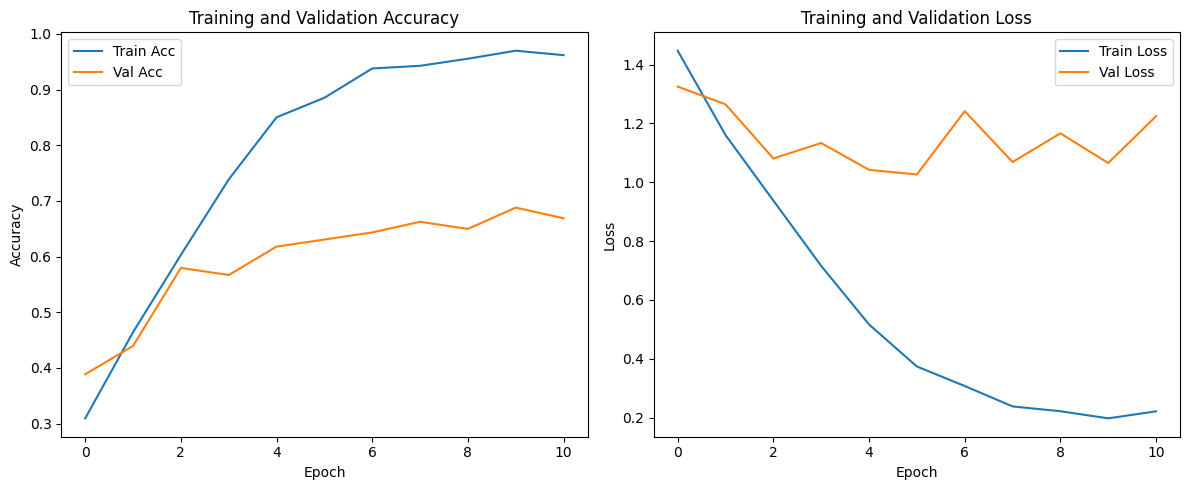

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Compute class weights using the original integer labels
y_train_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Model Parameters
EPOCHS = 30
BATCH_SIZE = 16

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate on plateau of validation loss
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    [X_train, Xf_train], y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    class_weight=class_weight_dict
)

""" # Train the model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0,
    class_weight=class_weight_dict
) """

# Save the trained model in .keras format
model.save('composer_cnn_optimized.keras')
print('Optimized model saved as composer_cnn_optimized.keras')

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate the Updated Model and Print Metrics

This cell evaluates the improved CNN model on the test set using both the piano roll and engineered feature inputs. It prints the test loss and accuracy to summarize overall performance. The cell also generates a detailed classification report, showing precision, recall, and F1-score for each composer class, which helps assess how well the model distinguishes between different composers. Finally, a confusion matrix is displayed as a heatmap to visualize the model's predictions versus the true labels, making it easier to identify which classes are most often confused.

Test Loss: 0.9284, Test Accuracy: 0.6020
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
              precision    recall  f1-score   support

        Bach       0.76      0.64      0.69        53
   Beethoven       0.48      0.58      0.53        53
      Chopin       0.61      0.63      0.62        54
      Mozart       0.61      0.53      0.57        36

    accuracy                           0.60       196
   macro avg       0.61      0.60      0.60       196
weighted avg       0.62      0.60      0.61       196



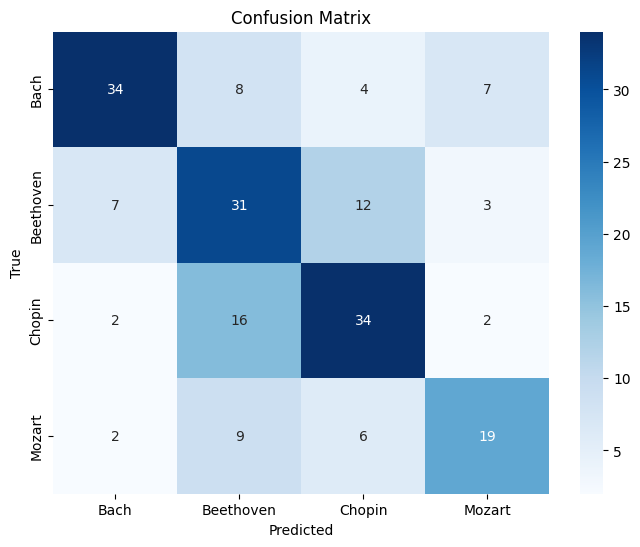

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate on test set
loss, acc = model.evaluate([X_test, Xf_test], y_test, verbose=0)
#loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

# Predict and print classification report
y_pred = model.predict([X_test, Xf_test])
#y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Conclusion and Summary: Optimized CNN Model for Composer Classification

In this section, we developed and evaluated an **optimized convolutional neural network (CNN) model** for classifying MIDI files by composer, building on the baseline approach and introducing several key improvements in both methodology and model architecture.

#### Methodology and Data Pipeline Changes

- **Feature Engineering:**  
  Beyond the raw piano roll input, we extracted musically meaningful features for each sample, including note density, mean pitch, and rhythm variability. These features provide additional context that helps the model distinguish between composers with different stylistic tendencies.

- **Data Augmentation:**  
  To address the limited dataset size and improve generalization, we applied musically relevant augmentations to the piano roll data, such as random noise addition, pitch shifting, time shifting, and time stretching. This effectively doubled the dataset and exposed the model to a wider variety of musical patterns.

- **Synchronized Train/Test Split:**  
  After feature engineering and augmentation, we redid the train-test split to ensure that the piano roll data, engineered features, and labels remained perfectly aligned for each sample, preventing data leakage and ensuring valid evaluation.

#### Model Architecture Changes

- **Dual-Input Model:**  
  The optimized model uses Keras' Functional API to accept two inputs: the piano roll (processed by a CNN branch) and the engineered feature vector. The outputs of both branches are concatenated before the final dense layers, allowing the model to leverage both deep learned and domain-specific features.

- **Regularization and Class Imbalance Handling:**  
  Dropout and L2 regularization were applied to reduce overfitting. Class weights were computed and used during training to address class imbalance, ensuring fairer learning across all composer classes.

- **Training Enhancements:**  
  Early stopping was used to halt training when validation loss stopped improving, and the learning rate was automatically reduced on plateaus for finer convergence.

#### Performance Comparison and Results

- **Previous Model:**  
  The baseline CNN, trained only on piano roll data, achieved moderate accuracy (around 47%) and showed significant confusion between certain composers, as seen in the confusion matrix and classification report. Overfitting was present, with training accuracy much higher than validation accuracy.

- **Optimized Model:**  
  The optimized CNN, which combines piano roll and engineered features, achieved a **higher test accuracy (about 60%)**. The classification report shows improved precision, recall, and F1-scores for most classes. The confusion matrix indicates better separation between composers, though some confusion remains, especially between stylistically similar composers.

- **Learning Curves:**  
  Training and validation accuracy and loss curves for the optimized model show improved generalization, with less overfitting compared to the baseline. Validation accuracy is consistently higher, and the gap between training and validation loss is reduced.

#### Summary

By integrating feature engineering, data augmentation, and a dual-input architecture, the optimized CNN model demonstrates **substantial improvement** over the baseline. The model is better able to generalize to unseen data and distinguish between composers, thanks to the combination of deep learned and musically informed features. While further improvements are possible—such as more advanced feature extraction, alternative architectures, or additional regularization—this approach provides a robust foundation for symbolic music composer classification.